#  KPIs (Indicateurs Clés)
**Projet** : Analyse des Offres d'Emploi au Sénégal — Volkeno

**KPIs analysés** :
- Compétences les plus recherchées
- Croissance mensuelle des offres
- Type de contrat dominant

##  Import des bibliothèques

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

print('Bibliothèques importées !')

Bibliothèques importées !


## Chargement des données

In [4]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
FILE     = os.path.join(BASE_DIR, 'data', 'cleaned', 'offres_emploi_senegal_cleaned.csv')

df = pd.read_csv(FILE, encoding='utf-8-sig')
print(f'Données chargées : {len(df)} offres')

# Parsing des dates
MOIS = {
    'janvier': '01', 'février': '02', 'mars': '03',
    'avril': '04', 'mai': '05', 'juin': '06',
    'juillet': '07', 'août': '08', 'septembre': '09',
    'octobre': '10', 'novembre': '11', 'décembre': '12',
    'janv.': '01', 'févr.': '02', 'avr.': '04',
    'juil.': '07', 'sept.': '09', 'oct.': '10',
    'nov.': '11', 'déc.': '12',
}

def parser_date(date_str):
    if pd.isna(date_str) or date_str == 'Non précisé':
        return pd.NaT
    date_str = str(date_str).strip().lower()
    for mois_fr, mois_num in MOIS.items():
        if mois_fr in date_str:
            date_str = date_str.replace(mois_fr, mois_num)
            break
    try:
        return pd.to_datetime(date_str, dayfirst=True)
    except:
        return pd.NaT

df['Date parsed'] = df['Date de publication'].apply(parser_date)
df['Mois']        = df['Date parsed'].dt.to_period('M')
print(f'Dates parsées : {df["Date parsed"].notna().sum()} / {len(df)}')

Données chargées : 3840 offres
Dates parsées : 3823 / 3840


## -- Compétences les plus recherchées

TOP 15 COMPÉTENCES LES PLUS RECHERCHÉES
         Compétence  Fréquence
       Informatique        458
              Vente        449
          Formation        423
          Recherche        350
            Finance        293
      Communication        206
       Comptabilité        196
        Recrutement        186
         Management        166
          Marketing        146
              Excel        132
         Logistique        128
               Sage        122
           Français        110
Ressources Humaines        101


C:\Users\HP\AppData\Local\Temp\ipykernel_15768\3824944168.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_competences, x='Compétence', y='Fréquence', palette='Oranges_r', ax=ax)


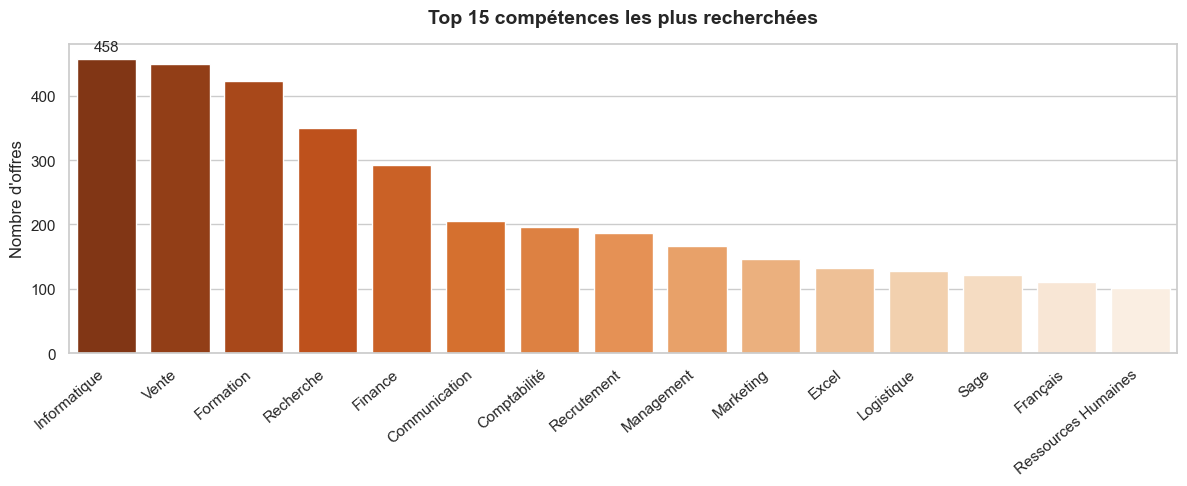

Graphique sauvegardé : kpi_competences.png


In [8]:
# Domaines de compétences à rechercher
COMPETENCES_CLES = {
    # Informatique & Tech
    'Excel': ['excel'],
    'Word': ['word'],
    'PowerPoint': ['powerpoint', 'power point'],
    'Python': ['python'],
    'SQL': ['sql'],
    'SAP': ['sap'],
    'ERP': ['erp'],
    'CRM': ['crm'],
    'Sage': ['sage'],
    'AutoCAD': ['autocad'],
    'Pack Office': ['pack office', 'office 365', 'microsoft office'],

    # Compétences transversales
    'Communication': ['communication', 'communicat'],
    'Management': ['management', 'manager', 'managérial'],
    'Comptabilité': ['comptabilité', 'comptable', 'compta'],
    'Finance': ['finance', 'financier', 'financière'],
    'Marketing': ['marketing', 'digital marketing'],
    'Vente': ['vente', 'commercial', 'commerciale'],
    'Ressources Humaines': ['ressources humaines', 'rh ', ' rh,'],
    'Juridique': ['juridique', 'droit', 'legal'],
    'Logistique': ['logistique', 'supply chain'],
    'Anglais': ['anglais', 'english'],
    'Français': ['français', 'french'],
    'Rédaction': ['rédaction', 'rédiger'],
    'Analyse de données': ['analyse des données', 'data analysis', 'analyse de données'],
    'Gestion de projet': ['gestion de projet', 'project management', 'chef de projet'],
    'Service client': ['service client', 'relation client', 'customer'],
    'Recherche': ['recherche', 'research'],
    'Formation': ['formation', 'training'],
    'Recrutement': ['recrutement', 'recruitment'],
    'Audit': ['audit', 'auditeur'],
    'Informatique': ['informatique', 'it ', ' it,'],
}

# Comptage
comptage = {}
for label, keywords in COMPETENCES_CLES.items():
    count = 0
    for comp in df['Compétences demandées'].dropna():
        if comp == 'Non précisé':
            continue
        comp_lower = comp.lower()
        if any(kw in comp_lower for kw in keywords):
            count += 1
    if count > 0:
        comptage[label] = count

# Top 15
top_competences = (
    pd.DataFrame(list(comptage.items()), columns=['Compétence', 'Fréquence'])
    .sort_values('Fréquence', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print('TOP 15 COMPÉTENCES LES PLUS RECHERCHÉES')
print('=' * 40)
print(top_competences.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top_competences, x='Compétence', y='Fréquence', palette='Oranges_r', ax=ax)
ax.set_title('Top 15 compétences les plus recherchées', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Nombre d\'offres')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('kpi_competences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_competences.png')

## -- Croissance mensuelle des offres

 CROISSANCE MENSUELLE DES OFFRES
Mois str  Nombre d'offres  Croissance (%)
 2024-07               78             NaN
 2024-08               22      -71.794872
 2024-09               31       40.909091
 2024-10               46       48.387097
 2024-11               41      -10.869565
 2024-12               10      -75.609756
 2025-01              269     2590.000000
 2025-02              289        7.434944
 2025-03              287       -0.692042
 2025-04              312        8.710801
 2025-05              235      -24.679487
 2025-06              281       19.574468
 2025-07              232      -17.437722
 2025-08              165      -28.879310
 2025-09              236       43.030303
 2025-10              324       37.288136
 2025-11              130      -59.876543
 2025-12              238       83.076923
 2026-01              258        8.403361
 2026-02              218      -15.503876
 2026-03              121      -44.495413

-- Croissance moyenne  : 126.8% / mois
-- 

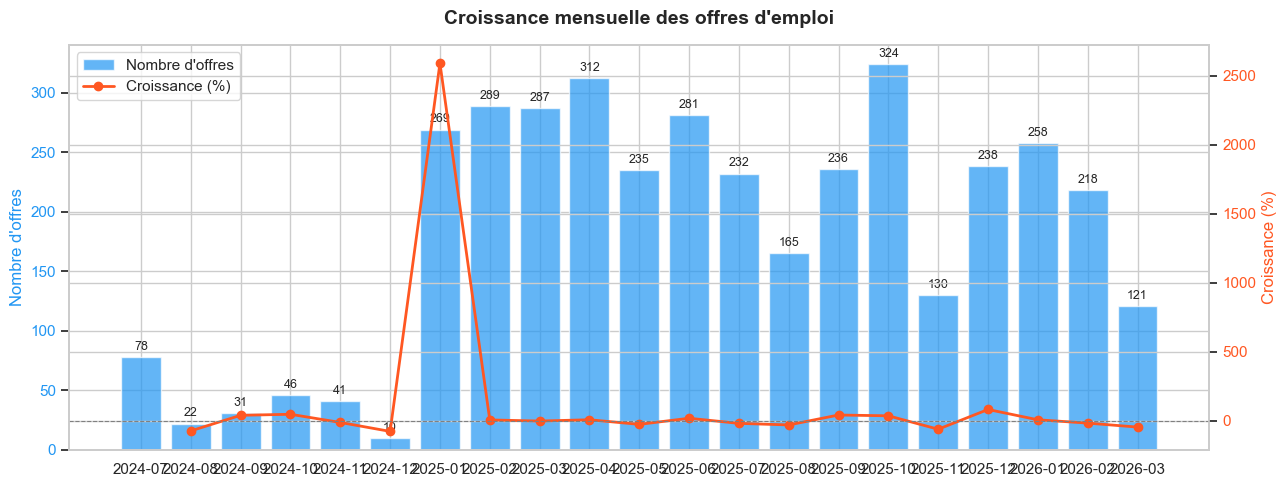

Graphique sauvegardé : kpi_croissance_mensuelle.png


In [10]:
evolution = (
    df[df['Mois'].notna()]
    .groupby('Mois')
    .size()
    .reset_index(name="Nombre d'offres")
    .sort_values('Mois')
)

# Calcul croissance mensuelle
evolution['Croissance (%)'] = evolution["Nombre d'offres"].pct_change() * 100
evolution['Mois str']       = evolution['Mois'].astype(str)

print(' CROISSANCE MENSUELLE DES OFFRES')
print('=' * 40)
print(evolution[['Mois str', "Nombre d'offres", 'Croissance (%)']].to_string(index=False))

# KPI global
croissance_moy = evolution['Croissance (%)'].mean()
mois_pic       = evolution.loc[evolution["Nombre d'offres"].idxmax(), 'Mois str']
nb_pic         = evolution["Nombre d'offres"].max()
print(f'\n-- Croissance moyenne  : {croissance_moy:.1f}% / mois')
print(f'-- Mois le plus actif  : {mois_pic} ({nb_pic} offres)')

# Visualisation
fig, ax1 = plt.subplots(figsize=(13, 5))

# Barres — nombre d'offres
bars = ax1.bar(evolution['Mois str'], evolution["Nombre d'offres"],
               color='#2196F3', alpha=0.7, label="Nombre d'offres")
ax1.set_ylabel("Nombre d'offres", color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.bar_label(bars, fmt='%d', padding=3, fontsize=9)

# Ligne — croissance
ax2 = ax1.twinx()
ax2.plot(evolution['Mois str'], evolution['Croissance (%)'],
         color='#FF5722', marker='o', linewidth=2, label='Croissance (%)')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Croissance (%)', color='#FF5722')
ax2.tick_params(axis='y', labelcolor='#FF5722')

ax1.set_title('Croissance mensuelle des offres d\'emploi', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('kpi_croissance_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_croissance_mensuelle.png')

## -- Type de contrat dominant

 TYPE DE CONTRAT DOMINANT
Type de contrat  Nombre  Pourcentage
  Temps complet    3045         80.5
            CDD     530         14.0
            CDI     124          3.3
          Stage      77          2.0
      Freelance       6          0.2

Contrat dominant : Temps complet (80.5%)


C:\Users\HP\AppData\Local\Temp\ipykernel_15768\626075505.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contrats, x='Type de contrat', y='Nombre', palette='Set2', ax=ax1)


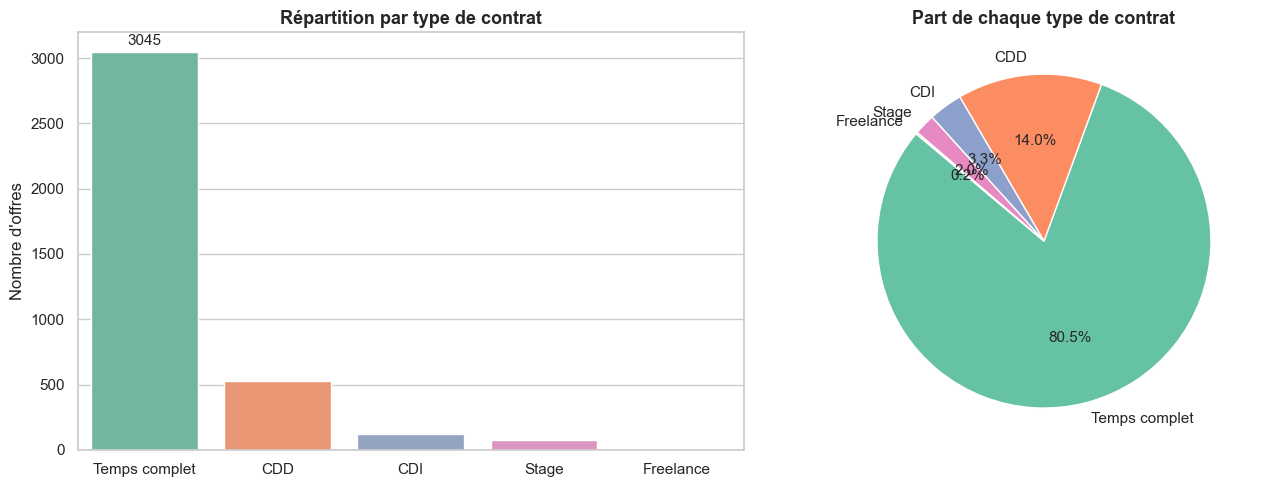

Graphique sauvegardé : kpi_contrats.png


In [11]:
contrats = (
    df[df['Type de contrat'] != 'Non précisé']['Type de contrat']
    .value_counts()
    .reset_index()
)
contrats.columns = ['Type de contrat', 'Nombre']
contrats['Pourcentage'] = (contrats['Nombre'] / contrats['Nombre'].sum() * 100).round(1)

# KPI global
dominant = contrats.iloc[0]
print(' TYPE DE CONTRAT DOMINANT')
print('=' * 40)
print(contrats.to_string(index=False))
print(f'\nContrat dominant : {dominant["Type de contrat"]} ({dominant["Pourcentage"]}%)')

# Visualisation — barplot + camembert côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
sns.barplot(data=contrats, x='Type de contrat', y='Nombre', palette='Set2', ax=ax1)
ax1.set_title('Répartition par type de contrat', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Nombre d\'offres')
ax1.bar_label(ax1.containers[0], fmt='%d', padding=3)

# Camembert
colors = sns.color_palette('Set2', len(contrats))
ax2.pie(
    contrats['Nombre'],
    labels=contrats['Type de contrat'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
ax2.set_title('Part de chaque type de contrat', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi_contrats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : kpi_contrats.png')